In [1]:
# Steel model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from scipy.optimize import OptimizeWarning
warnings.simplefilter('ignore', OptimizeWarning)

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (all_regions_list_class, 
                                          models_output_dict)

In [2]:
# Steel
steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                       image_mat_available = True, start_year = 1971, 
                       convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                       trade_data=True)


high = ['class_ 19', 'class_ 20']

medium = ['class_ 1','class_ 13', 'class_ 16', 'class_ 23'] 

low = ['class_ 2',  'class_ 3', 'class_ 11' , 'class_ 24']

# trajectory not to forseen, will be fitted with global regression
low_gdp = ['class_ 4', 'class_ 5', 'class_ 6', 'class_ 7',
           'class_ 8', 'class_ 9',  'class_ 10', 'class_ 12',
           'class_ 15', 'class_ 17', 'class_ 18', 'class_ 21', 
           'class_ 22', 'class_ 25', 'class_ 26']

# what is in rset will not be fitted because of outliers - will follow global projections       
rest = all_regions_list_class[:-1]
rest = [r for r in rest if r not in (high+low+medium+low_gdp)]

# for these models a regression will be made
# all reginos that are not in the high, medium, low will be fitted with the global regression
steel_grouping = {'all' : all_regions_list_class[:-1],
                  'high': high,
                  'medium': medium,
                  'low': low,
                  }

#steel_grouping = {'all' : all_regions_list_class[:-1]}
steel.data_grouped_regions(regions_grouping = steel_grouping)

# get drivers for fitting (regions dont need to be summed, regions dict is none)
steel.sum_IMAGE_drivers_regions(regions_dict=None)

steel.match_MAT_data_to_regions_year(match_external_regions=False)
steel.calculate_historic_other_fraction()

In [3]:
# Share of IAMGE MAT data to total consumption
share_mat_total = (steel.image_mat_data/steel.historic_consumption_data*100).mean()

In [4]:
# deal with regions where there are negative values because consumption was lower than mat projections

# too many negative: class 4, 8, 9, 22, 25, 26
# assumption: IMAGE MATERIALS is overestimating, 
# real consumption numbers are true &  
# TODO: MATERIALS calculations should be scaled down accordingly 

neg_classes = ['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']
steel.historic_other_fraction_consumption[neg_classes] = steel.historic_consumption_data[neg_classes]

# deal with single negative numbers by removing them from dataset
steel.historic_other_fraction_consumption[steel.historic_other_fraction_consumption < 0] = np.nan


In [5]:

# Fit models 
steel.calculate_regressors(steel.historic_other_fraction_consumption)

# enforce that for all groups gompertz model is selected as best fit
steel.fit_models(best_rmse_models={'all' : 'gompertz model',
                                   'high': 'gompertz model',
                                   'medium': 'gompertz model',
                                   'low': 'gompertz model'})


# project based on best model
steel.project_on_total(all_regions_list_class[:-1])

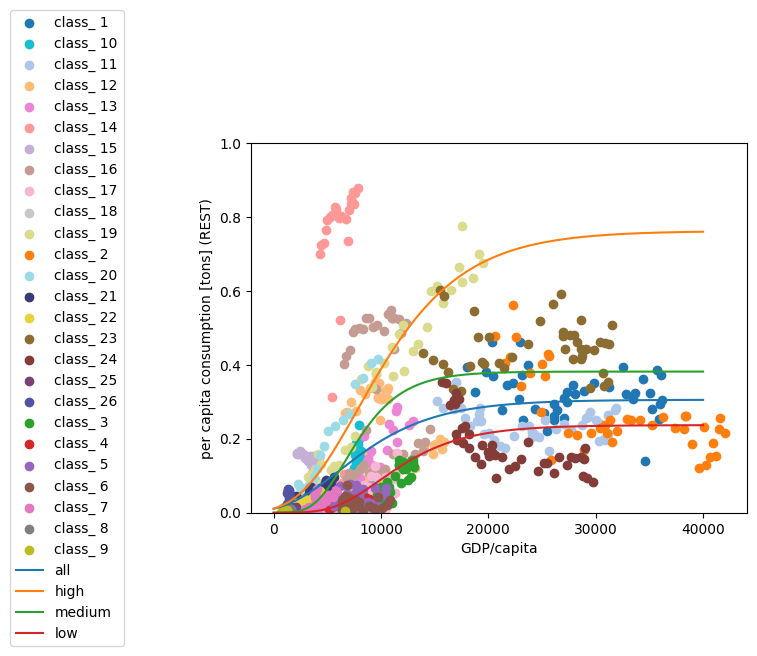

In [6]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', "#EB85D5", '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', "#E4D33D", '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in steel.cons_capita.columns:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in steel_grouping.keys():
    model = steel.model_groups[grouping][models_output_dict[steel.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40001).reshape(-1, 1)),
            label = grouping)

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")

# set ax limits
ax.set_ylim(0, 1)

ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))


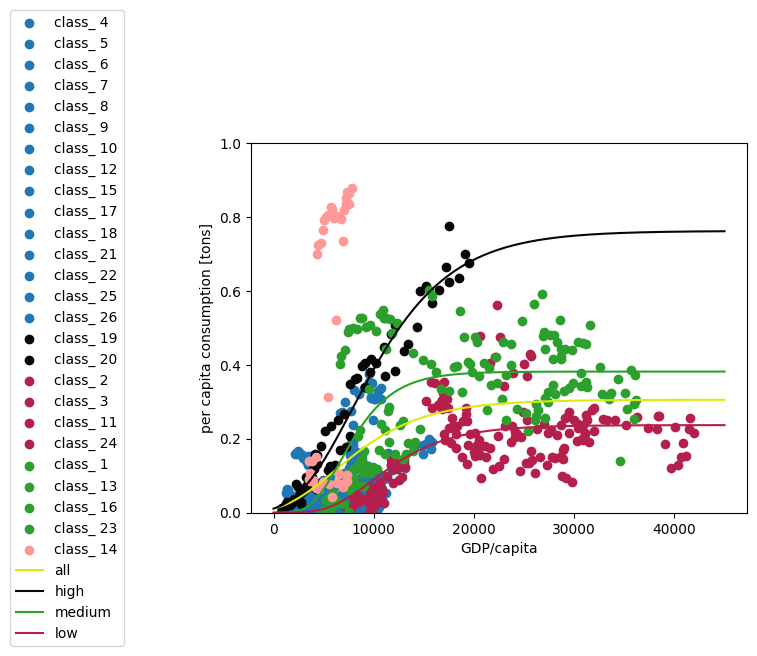

In [7]:
# Grouping of regions for fitting

color_low_gdp = '#1f77b4'
color_low = "#b41f4c"
color_high = "#070707"
color_medium = '#2ca02c'

color_dict_fits = {
    'low_gdp': color_low_gdp,
    'low': color_low,
    'medium': color_medium,
    'high': color_high,
    'all': "#dceb0c",  # Color for all regions

}


fig, ax = plt.subplots()             # Create a figure containing a single Axes.
for region in low_gdp:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_low_gdp)
    
for region in high:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_high)

for region in low:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_low)

for region in medium:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_medium)

for region in rest:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in steel_grouping.keys():
    model = steel.model_groups[grouping][models_output_dict[steel.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])

# set ax limits
ax.set_ylim(0, 1)


ax.set_ylabel("per capita consumption [tons]")
ax.set_xlabel("GDP/capita")
plt.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))

In [8]:

steel.smooth_out_interpolation_all(10, 2012)

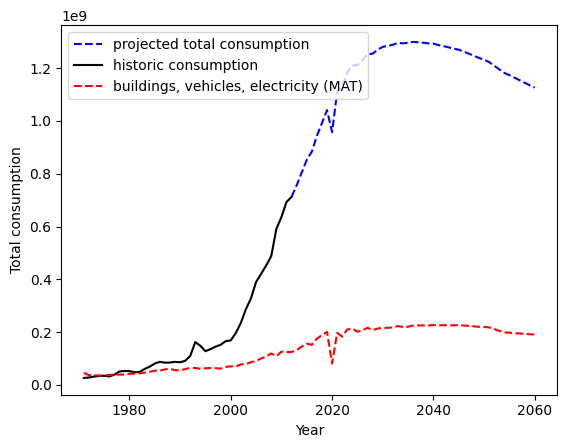

In [9]:
from imagematerials.rest_of.visualization import plot_overview_figure_total_consumption_region
    
plot_overview_figure_total_consumption_region(steel, ["class_ 20"])

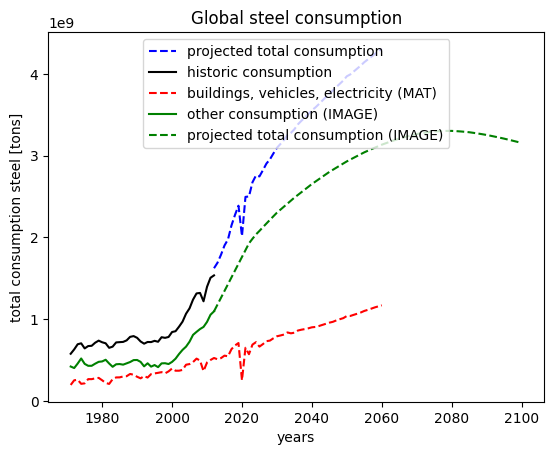

In [10]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(steel.projection_per_region_total.sum(axis = 1) + steel.image_mat_data.sum(axis = 1).loc[2012:], 
        linestyle = '--', color = 'blue', label = 'projected total consumption')
ax.plot(steel.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(steel.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')
ax.plot(steel.historic_other_fraction_consumption.sum(axis = 1),
        linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')

ax.plot(steel.projection_per_region_total.loc[2012: ].sum(axis = 1),
        linestyle = '--', color = 'green', label = 'projected total consumption (IMAGE)')

ax.set_ylabel("total consumption steel [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global steel consumption")
ax.legend(loc = 'upper center')

In [11]:
region = 'class_ 1'

# 1) Get coefs from projection
coefs_standard = steel.region_model_match.get(region)._coefs
print(coefs_standard)

# 2) Get X to project
# Plot diffferent regions with Gompertz fit
X_axis = np.arange(1, 40001).reshape(-1, 1) # GDP/capita input for Gompertz fit
X_input = np.arange(1, 40001).reshape(-1, 1)/1000  # GDP/capita input for Gompertz fit


# 3) make a of coefs dependent from X --> try: 1% decrease in coefs for 1% increase in X
def adjust_a_gompertz(coefs_standard, X_input):
    """
    Adjust the Gompertz coefficients based on GDP/capita input.
    Only adjust if GDP/cap is higher than 30_000.

    """
    a = coefs_standard[0]
    # now make a dependet from X if X is higher than 30_000, when X lower than 30_000, a is not adjusted
    adjusted_a = np.where(X_input > 25, a * (1 - 0.01 * (X_input - 25)), a)
    return adjusted_a
    

adjusted_a = adjust_a_gompertz(coefs_standard, X_input)

def gompertz_function(X, a, b, c):
    """
    Gompertz function.
    """
    return a * np.exp(-b * np.exp(-c * X))


y_adjusted = gompertz_function(X_input, adjusted_a, coefs_standard[1], coefs_standard[2])
y_standard = gompertz_function(X_input, coefs_standard[0], coefs_standard[1], coefs_standard[2])

# 4) find a way to adapt for all regions in a systematic approach

[ 0.38188809 10.          3.44197952]


In [12]:
# get coefs from projection for all regions
general_coefs = steel.model_groups.get('all')[6]._coefs

# from a gdp/cap of 20_000, a is adjusted to reach general coefs

def adjust_a_gompertz_all_regions(coefs_standard, X_input):
    """
    Adjust the Gompertz coefficients based on GDP/capita input.
    Only adjust if GDP/cap is higher than 20_000.
    """
    a = coefs_standard[0]
    # now make a dependet from X if X is higher than 20_000, when X lower than 20_000, a is not adjusted
    adjusted_a = np.where(X_input > 20, a * (1 - 0.01 * (X_input - 20)), a)
    return adjusted_a



In [13]:
steel.region_model_match

{'class_ 1': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1db07a5e270>,
 'class_ 2': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1db07a5fec0>,
 'class_ 3': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1db07a5fec0>,
 'class_ 4': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1db07990b60>,
 'class_ 5': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1db07990b60>,
 'class_ 6': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1db07990b60>,
 'class_ 7': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1db07990b60>,
 'class_ 8': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1db07990b60>,
 'class_ 9': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1db07990b60>,
 'class_ 10': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1db07990b60>,
 'class_ 11': <imagematerials

In [14]:
# export coefs frmo steel.region_model_match to csv file

for region in steel.region_model_match.keys():
    coefs = steel.region_model_match.get(region)._coefs
    print(f"{region}: {coefs}")

# export coefs to csv file
coefs_df = pd.DataFrame.from_dict({region: steel.region_model_match.get(region)._coefs for region in steel.region_model_match.keys()}, orient='index',
                                   columns=['a', 'b', 'c'])

# rename regions to nr as str
coefs_df.index = [region.split('_ ')[-1] for region in coefs_df.index]
coefs_df.to_csv('steel_region_model_coefs.csv')



class_ 1: [ 0.38188809 10.          3.44197952]
class_ 2: [ 0.23701558 10.          2.33410975]
class_ 3: [ 0.23701558 10.          2.33410975]
class_ 4: [0.30567592 3.35749682 2.00361384]
class_ 5: [0.30567592 3.35749682 2.00361384]
class_ 6: [0.30567592 3.35749682 2.00361384]
class_ 7: [0.30567592 3.35749682 2.00361384]
class_ 8: [0.30567592 3.35749682 2.00361384]
class_ 9: [0.30567592 3.35749682 2.00361384]
class_ 10: [0.30567592 3.35749682 2.00361384]
class_ 11: [ 0.23701558 10.          2.33410975]
class_ 12: [0.30567592 3.35749682 2.00361384]
class_ 13: [ 0.38188809 10.          3.44197952]
class_ 14: [0.30567592 3.35749682 2.00361384]
class_ 15: [0.30567592 3.35749682 2.00361384]
class_ 16: [ 0.38188809 10.          3.44197952]
class_ 17: [0.30567592 3.35749682 2.00361384]
class_ 18: [0.30567592 3.35749682 2.00361384]
class_ 19: [0.76241715 4.22416454 1.83534748]
class_ 20: [0.76241715 4.22416454 1.83534748]
class_ 21: [0.30567592 3.35749682 2.00361384]
class_ 22: [0.30567592 3.

In [15]:
coefs_df

,a,b,c
1,0.381888,10.000000,3.441980
2,0.237016,10.000000,2.334110
3,0.237016,10.000000,2.334110
4,0.305676,3.357497,2.003614
5,0.305676,3.357497,2.003614
6,0.305676,3.357497,2.003614
7,0.305676,3.357497,2.003614
8,0.305676,3.357497,2.003614
9,0.305676,3.357497,2.003614
10,0.305676,3.357497,2.003614
